<a href="https://colab.research.google.com/github/mamontoff2018-lgtm/google-colab/blob/main/MO4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd

%matplotlib inline

import seaborn as sns
from matplotlib import pyplot as plt

data_source = 'iris.csv'
d = pd.read_table(data_source, delimiter=',',
                  header=None,
                  names=['sepal_length','sepal_width',
                         'petal_length','petal_width','answer'])

dX = d.iloc[:, 0:4]
dy = d['answer']
print(dX.head())
print(dy.head())

   sepal_length  sepal_width  petal_length  petal_width
0  sepal_length  sepal_width  petal_length  petal_width
1           5.1          3.5           1.4          0.2
2           4.9          3.0           1.4          0.2
3           4.7          3.2           1.3          0.2
4           4.6          3.1           1.5          0.2
0    species
1     setosa
2     setosa
3     setosa
4     setosa
Name: answer, dtype: object


In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np

iris = pd.read_csv('iris.csv')

from sklearn.datasets import load_iris
iris_data = load_iris()
dX = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
dy = pd.Series(iris_data.target)

dX = dX.astype(float)
dy = dy.astype(int)

# Разделяем данные на обучающую и тестовую выборки
X_train, X_holdout, y_train, y_holdout = train_test_split(
    dX, dy, test_size=0.3, random_state=12
)

# Обучение модели
tree = DecisionTreeClassifier(max_depth=5,
                              random_state=21,
                              max_features=2)

tree.fit(X_train, y_train)

# Получение оценки hold-out
tree_pred = tree.predict(X_holdout)
accur = accuracy_score(y_holdout, tree_pred)
print(accur)


0.9777777777777777


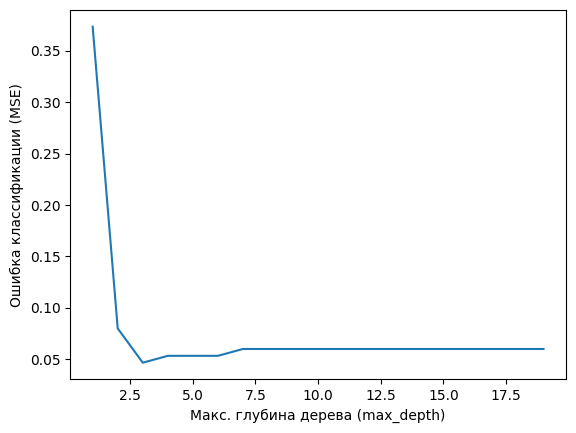

Оптимальные значения max_depth:  [3]


In [8]:
from sklearn.model_selection import cross_val_score

d_list = list(range(1,20))
cv_scores = []
for d in d_list:
    tree = DecisionTreeClassifier(max_depth=d,
                                   random_state=21,
                                   max_features=2)
    scores = cross_val_score(tree, dX, dy, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())

# Вычисляем ошибку
MSE = [1-x for x in cv_scores]

plt.plot(d_list, MSE)
plt.xlabel('Макс. глубина дерева (max_depth)');
plt.ylabel('Ошибка классификации (MSE)')
plt.show()

d_min = min(MSE)
# Пробуем найти прочие минимумы
all_d_min = []
for i in range(len(MSE)):
    if MSE[i] <= d_min:
        all_d_min.append(d_list[i])

print('Оптимальные значения max_depth: ', all_d_min)

In [9]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn import tree

dtc = DecisionTreeClassifier(max_depth=10, random_state=21, max_features=2)

tree_params = { 'max_depth': range(1,20), 'max_features': range(1,4) }
tree_grid = GridSearchCV(dtc, tree_params, cv=10, verbose=True, n_jobs=-1)
tree_grid.fit(dX, dy)

print('\n')
print('Лучшее сочетание параметров: ', tree_grid.best_params_)
print('Лучшие баллы cross validation: ', tree_grid.best_score_)

# Генерируем графическое представление дерева
tree.export_graphviz(tree_grid.best_estimator_,
                     feature_names=dX.columns,
                     class_names=dy.unique(),
                     out_file='iris_tree.dot',
                     filled=True, rounded=True)

Fitting 10 folds for each of 57 candidates, totalling 570 fits


Лучшее сочетание параметров:  {'max_depth': 2, 'max_features': 3}
Лучшие баллы cross validation:  0.9533333333333334


AttributeError: 'numpy.int64' object has no attribute 'replace'

In [10]:
# Построим области решения для оптимального дерева
# max_features = 2, max_depth = 3

dtc = DecisionTreeClassifier(max_depth=3,
                             random_state=21,
                             max_features=2)
dtc.fit(dX, dy)
res = dtc.predict([[5.1, 3.5, 1.4, 0.2]])
print(res)

[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


/tmp/ipykernel_6778/3386615059.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  xx, yy = np.meshgrid(np.arange(fmin[i], fmax[i], plot_step),
/tmp/ipykernel_6778/3386615059.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  np.arange(fmin[j], fmax[j], plot_step))
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/tmp/ipykernel_6778/3386615059.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will alwa

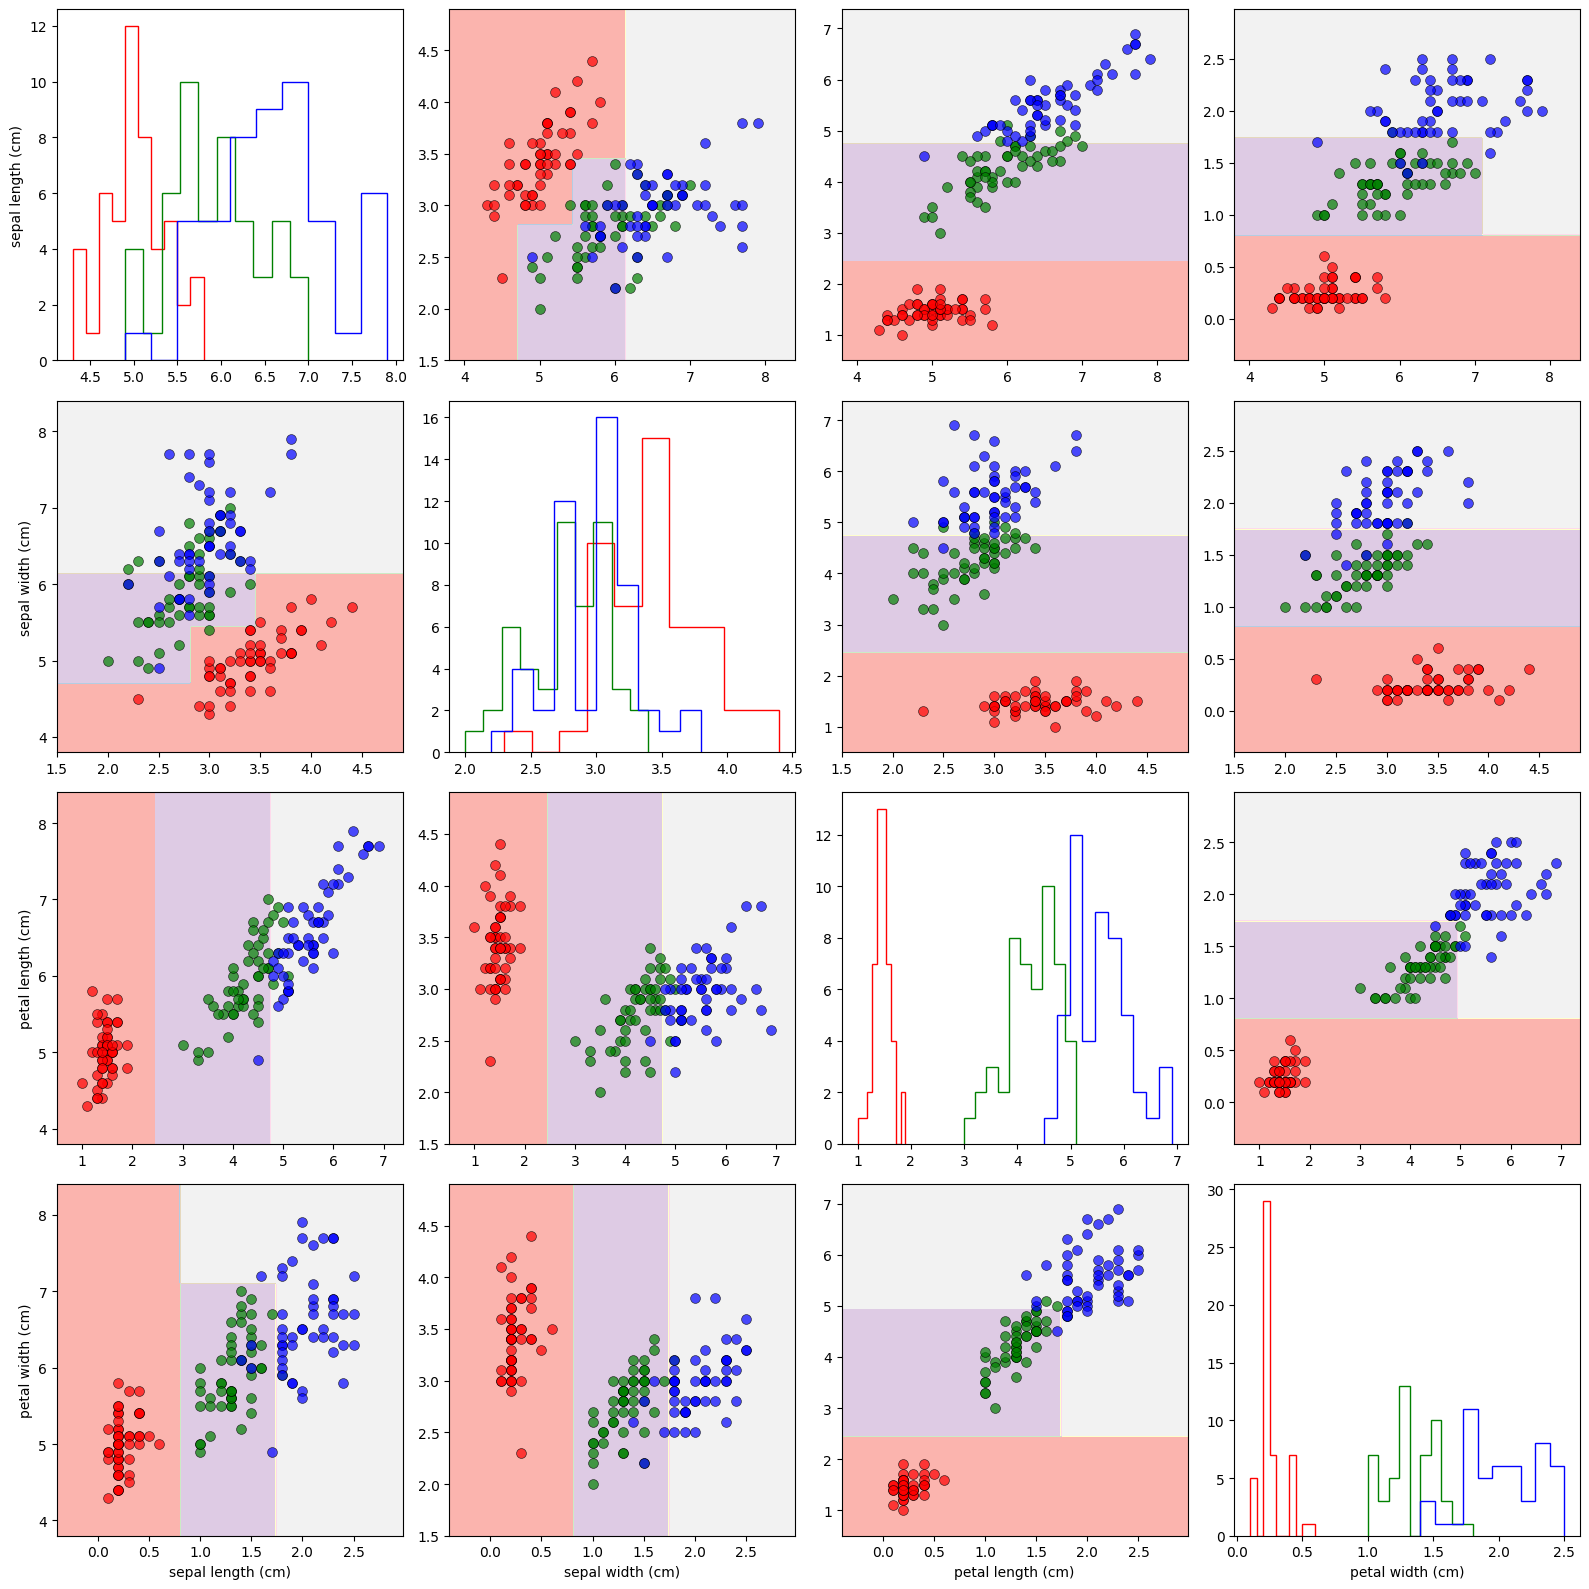

In [24]:
plot_markers = ['r', 'g', 'b']
answers = dy.unique()

f, places = plt.subplots(4, 4, figsize=(16,16))

fmin = dX.min()-0.5
fmax = dX.max()+0.5
plot_step = 0.02

for i in range(0,4):
    for j in range(0,4):

        if(i != j):
            xx, yy = np.meshgrid(np.arange(fmin[i], fmax[i], plot_step),
                                 np.arange(fmin[j], fmax[j], plot_step))
            model = DecisionTreeClassifier(max_depth=3, random_state=21, max_features=2)
            model.fit(dX.iloc[:, [i,j]], dy)
            p = model.predict(np.c_[xx.ravel(), yy.ravel()])
            p = p.reshape(xx.shape)
            p[p==answers[0]] = 0
            p[p==answers[1]] = 1
            p[p==answers[2]] = 2
            places[i,j].contourf(xx, yy, p, cmap='Pastel1')

        for id_answer in range(len(answers)):
            idx = np.where(dy == answers[id_answer])
            if i==j:
                places[i, j].hist(dX.iloc[idx].iloc[:, i],
                                  color=plot_markers[id_answer],
                                  histtype='step')
            else:
                places[i, j].scatter(dX.iloc[idx].iloc[:, i],
                                    dX.iloc[idx].iloc[:, j],
                                    c=plot_markers[id_answer],
                                    label=answers[id_answer],
                                    s=50,
                                    alpha=0.7,
                                    edgecolors='black',
                                    linewidth=0.5)

            if j==0:
                places[i, j].set_ylabel(dX.columns[i])

            if i==3:
                places[i, j].set_xlabel(dX.columns[j])

plt.tight_layout()
plt.show()

In [25]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

wine_data = load_wine()
X = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
y = pd.Series(wine_data.target)

print("Характеристики датасета:")
print(f"Количество объектов: {X.shape[0]}")
print(f"Количество признаков: {X.shape[1]}")
print(f"Количество классов: {len(y.unique())}")
print(f"Распределение классов: {y.value_counts().sort_index().to_dict()}")
print("\nНазвания признаков:")
print(X.columns.tolist())

# Разделяем данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


dtc = DecisionTreeClassifier(
    max_depth=4,
    max_features=5,
    random_state=42
)

dtc.fit(X_train, y_train)

# Оценка модели
y_pred = dtc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nТочность классификатора (max_depth=4, max_features=5): {accuracy:.4f}")

Характеристики датасета:
Количество объектов: 178
Количество признаков: 13
Количество классов: 3
Распределение классов: {0: 59, 1: 71, 2: 48}

Названия признаков:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Точность классификатора (max_depth=4, max_features=5): 0.8333


In [26]:
export_graphviz(
    dtc,
    out_file='wine_tree.dot',
    feature_names=X.columns,
    class_names=['Wine_0', 'Wine_1', 'Wine_2'],
    filled=True,
    rounded=True,
    special_characters=True
)

# Конвертация .dot файла в PNG (требует graphviz)
import os
os.system('dot -Tpng wine_tree.dot -o wine_tree_initial.png')

Дерево сохранено в wine_tree_initial.png


In [54]:
from sklearn.model_selection import cross_val_score

# Параметры для анализа
depth_range = range(1, 15)
cv_scores_depth = []
cv_mse_depth = []

print("Анализ влияния max_depth на производительность:")
print("max_depth | Mean Accuracy | MSE")

for depth in depth_range:
    dtc_temp = DecisionTreeClassifier(
        max_depth=depth,
        max_features=5,
        random_state=42
    )

    scores = cross_val_score(
        dtc_temp, X, y, cv=10, scoring='accuracy'
    )

    # Вычисляем MSE как 1 - accuracy
    mse = 1 - scores.mean()

    cv_scores_depth.append(scores.mean())
    cv_mse_depth.append(mse)

    print(f"{depth:9d} | {scores.mean():13.4f} | {mse:.4f}")

# Поиск оптимальной глубины
optimal_depth = depth_range[np.argmin(cv_mse_depth)]
print(f"\nОптимальное значение max_depth: {optimal_depth}")

Анализ влияния max_depth на производительность:
max_depth | Mean Accuracy | MSE
        1 |        0.5850 | 0.4150
        2 |        0.8830 | 0.1170
        3 |        0.8722 | 0.1278
        4 |        0.8833 | 0.1167
        5 |        0.8833 | 0.1167
        6 |        0.8833 | 0.1167
        7 |        0.8833 | 0.1167
        8 |        0.8833 | 0.1167
        9 |        0.8833 | 0.1167
       10 |        0.8833 | 0.1167
       11 |        0.8833 | 0.1167
       12 |        0.8833 | 0.1167
       13 |        0.8833 | 0.1167
       14 |        0.8833 | 0.1167

Оптимальное значение max_depth: 4


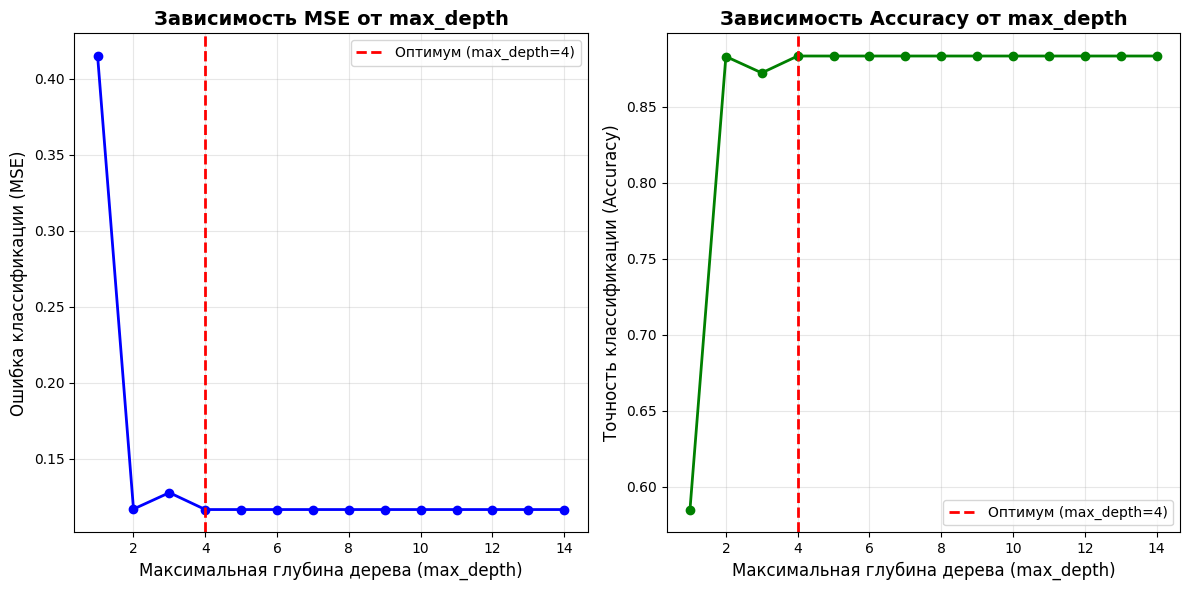

In [29]:
plt.figure(figsize=(12, 6))
# График MSE
plt.subplot(1, 2, 1)
plt.plot(depth_range, cv_mse_depth, 'b-o', linewidth=2, markersize=6)
plt.xlabel('Максимальная глубина дерева (max_depth)', fontsize=12)
plt.ylabel('Ошибка классификации (MSE)', fontsize=12)
plt.title('Зависимость MSE от max_depth', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axvline(x=optimal_depth, color='r', linestyle='--', linewidth=2, label=f'Оптимум (max_depth={optimal_depth})')
plt.legend()
# График точности
plt.subplot(1, 2, 2)
plt.plot(depth_range, cv_scores_depth, 'g-o', linewidth=2, markersize=6)
plt.xlabel('Максимальная глубина дерева (max_depth)', fontsize=12)
plt.ylabel('Точность классификации (Accuracy)', fontsize=12)
plt.title('Зависимость Accuracy от max_depth', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axvline(x=optimal_depth, color='r', linestyle='--', linewidth=2, label=f'Оптимум (max_depth={optimal_depth})')
plt.legend()

plt.tight_layout()
plt.show()


In [30]:
features_range = range(1, 14)  #13 признаков
cv_scores_features = []
cv_mse_features = []

print("\nАнализ влияния max_features на производительность:")
print("max_features | Mean Accuracy | MSE")
print("-" * 38)

for features in features_range:
    dtc_temp = DecisionTreeClassifier(
        max_depth=4,  
        max_features=features,
        random_state=42
    )

    # Кросс-валидация с 10 фолдами
    scores = cross_val_score(
        dtc_temp, X, y, cv=10, scoring='accuracy'
    )

    # Вычисляем MSE как 1 - accuracy
    mse = 1 - scores.mean()

    cv_scores_features.append(scores.mean())
    cv_mse_features.append(mse)

    print(f"{features:12d} | {scores.mean():13.4f} | {mse:.4f}")

# Поиск оптимального количества признаков
optimal_features = list(features_range)[np.argmin(cv_mse_features)]
print(f"\nОптимальное значение max_features: {optimal_features}")


Анализ влияния max_features на производительность:
max_features | Mean Accuracy | MSE
--------------------------------------
           1 |        0.8771 | 0.1229
           2 |        0.8889 | 0.1111
           3 |        0.9278 | 0.0722
           4 |        0.8993 | 0.1007
           5 |        0.8833 | 0.1167
           6 |        0.9052 | 0.0948
           7 |        0.9163 | 0.0837
           8 |        0.8820 | 0.1180
           9 |        0.8882 | 0.1118
          10 |        0.8716 | 0.1284
          11 |        0.8595 | 0.1405
          12 |        0.8817 | 0.1183
          13 |        0.8595 | 0.1405

Оптимальное значение max_features: 3


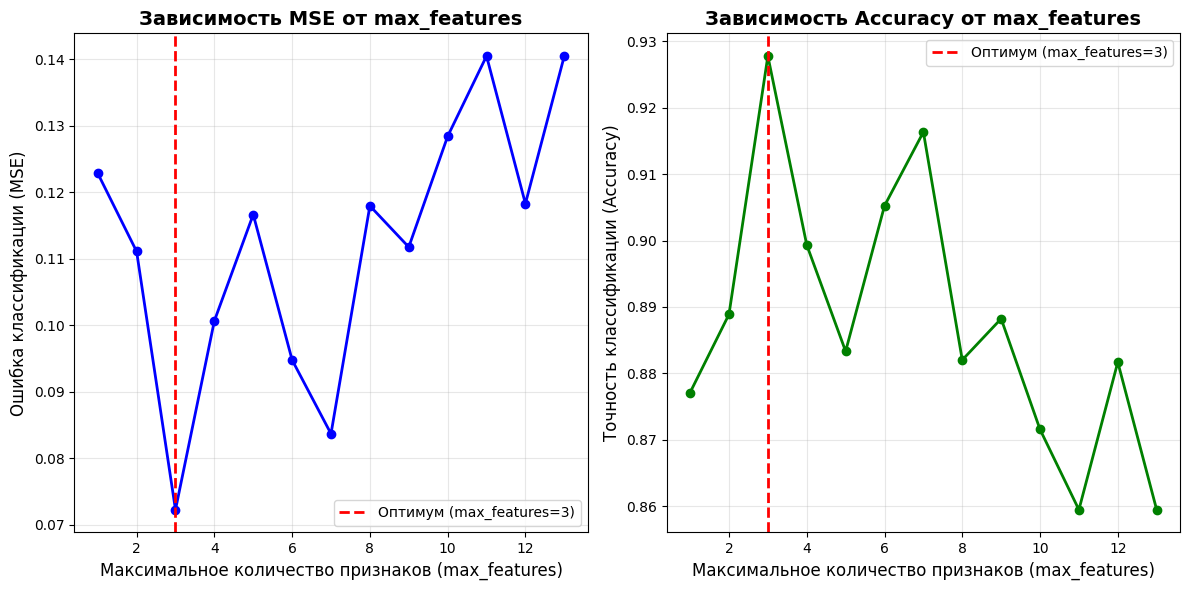

In [32]:
plt.figure(figsize=(12, 6))
# График MSE
plt.subplot(1, 2, 1)
plt.plot(features_range, cv_mse_features, 'b-o', linewidth=2, markersize=6)
plt.xlabel('Максимальное количество признаков (max_features)', fontsize=12)
plt.ylabel('Ошибка классификации (MSE)', fontsize=12)
plt.title('Зависимость MSE от max_features', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axvline(x=optimal_features, color='r', linestyle='--', linewidth=2, label=f'Оптимум (max_features={optimal_features})')
plt.legend()
# График точности
plt.subplot(1, 2, 2)
plt.plot(features_range, cv_scores_features, 'g-o', linewidth=2, markersize=6)
plt.xlabel('Максимальное количество признаков (max_features)', fontsize=12)
plt.ylabel('Точность классификации (Accuracy)', fontsize=12)
plt.title('Зависимость Accuracy от max_features', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axvline(x=optimal_features, color='r', linestyle='--', linewidth=2, label=f'Оптимум (max_features={optimal_features})')
plt.legend()

plt.tight_layout()
plt.show()



In [34]:
from sklearn.model_selection import GridSearchCV

base_dtc = DecisionTreeClassifier(random_state=42)

param_grid = {
    'max_depth': range(2, 12),
    'max_features': range(2, 10)
}

# GridSearchCV для поиска оптимальных параметров
grid_search = GridSearchCV(
    base_dtc,
    param_grid,
    cv=10,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X, y)


# Извлечение оптимальных параметров
optimal_max_depth = grid_search.best_params_['max_depth']
optimal_max_features = grid_search.best_params_['max_features']

print(f"\nОптимальное max_depth: {optimal_max_depth}")
print(f"Оптимальное max_features: {optimal_max_features}")

Fitting 10 folds for each of 80 candidates, totalling 800 fits

Оптимальное max_depth: 4
Оптимальное max_features: 3


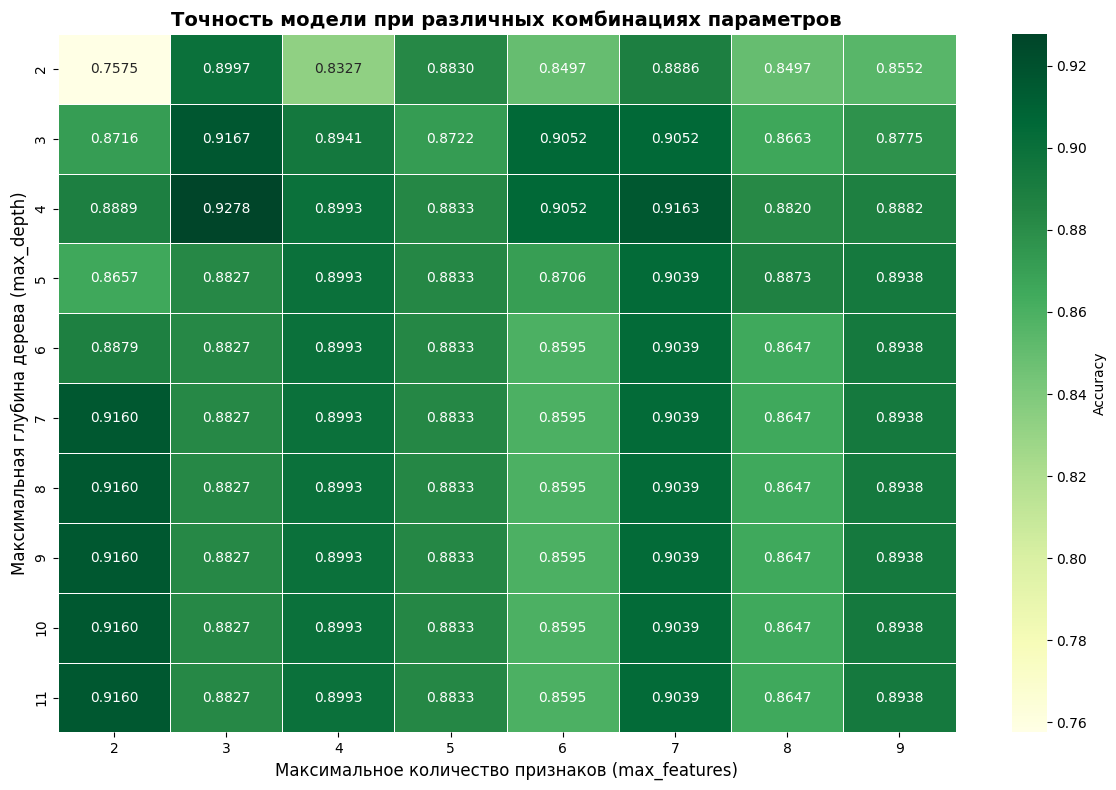

Выбранные параметры: max_depth=4, max_features=3
Точность на кросс-валидации: 0.9278


In [55]:
results_df = pd.DataFrame(grid_search.cv_results_)
results_pivot = results_df.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_max_features'
)

# Визуализация тепловой карты результатов
plt.figure(figsize=(12, 8))
import seaborn as sns

sns.heatmap(
    results_pivot,
    annot=True,
    fmt='.4f',
    cmap='YlGn',
    cbar_kws={'label': 'Accuracy'},
    linewidths=0.5
)
plt.xlabel('Максимальное количество признаков (max_features)', fontsize=12)
plt.ylabel('Максимальная глубина дерева (max_depth)', fontsize=12)
plt.title('Точность модели при различных комбинациях параметров', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('wine_gridsearch_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Выбранные параметры: max_depth={optimal_max_depth}, max_features={optimal_max_features}")
print(f"Точность на кросс-валидации: {grid_search.best_score_:.4f}")


In [40]:
# Создание оптимального классификатора
optimal_dtc = DecisionTreeClassifier(
    max_depth=optimal_max_depth,
    max_features=optimal_max_features,
    random_state=42
)

optimal_dtc.fit(X, y)


y_pred_optimal = optimal_dtc.predict(X_test)
accuracy_optimal = accuracy_score(y_test, y_pred_optimal)

print(f"Точность оптимального классифиccатора на тестовой выборке: {accuracy_optimal:.4f}")


export_graphviz(
    optimal_dtc,
    out_file='wine_tree_optimal.dot',
    feature_names=X.columns,
    class_names=['Wine_Class_0', 'Wine_Class_1', 'Wine_Class_2'],
    filled=True,
    rounded=True,
    special_characters=True,
    proportion=True
)

os.system('dot -Tpng wine_tree_optimal.dot -o wine_tree_optimal.png')

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': optimal_dtc.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nВажность признаков в оптимальной модели:")
print(feature_importance.to_string(index=False))

Точность оптимального классифиccатора на тестовой выборке: 0.9444

Важность признаков в оптимальной модели:
                     Feature  Importance
             color_intensity    0.322471
                     alcohol    0.262329
               total_phenols    0.262182
                  flavanoids    0.067524
           alcalinity_of_ash    0.038467
                  malic_acid    0.034023
                     proline    0.013005
                   magnesium    0.000000
                         ash    0.000000
             proanthocyanins    0.000000
        nonflavanoid_phenols    0.000000
                         hue    0.000000
od280/od315_of_diluted_wines    0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local

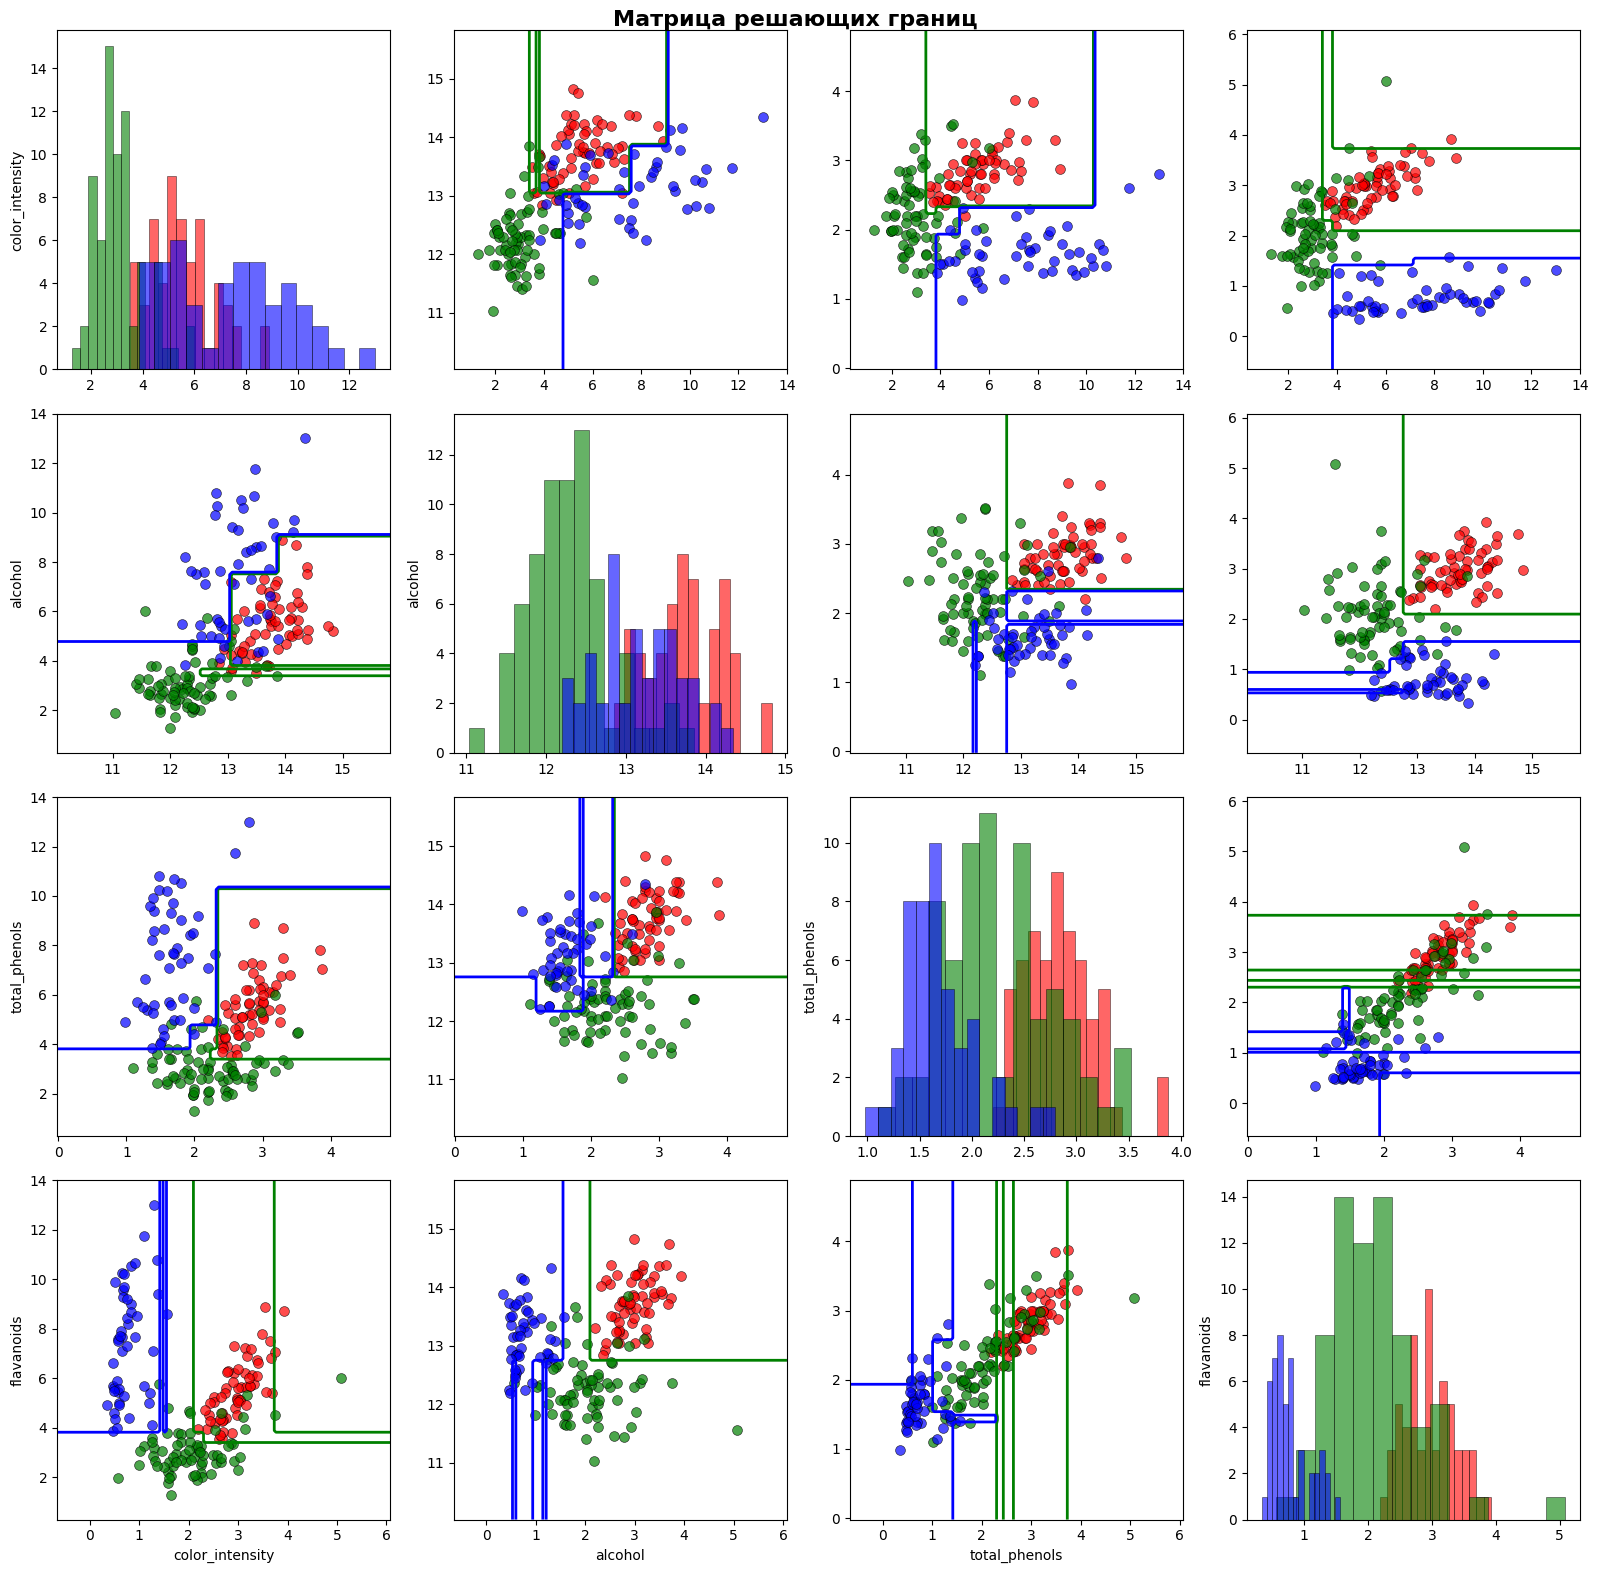

In [53]:
# Матрица решающих границ для 4 лучших признаков
n_features = 4
top_features = feature_importance['Feature'].head(n_features).tolist()
feature_indices = [X.columns.get_loc(feat) for feat in top_features]

fig, axes = plt.subplots(n_features, n_features, figsize=(16, 16))
colors = ['red', 'green', 'blue']

for i in range(n_features):
    for j in range(n_features):
        ax = axes[i, j]

        if i == j:
            # Гистограмма на диагонали
            for class_idx, color in enumerate(colors):
                mask = (y == class_idx).values
                data = X.iloc[mask, feature_indices[i]]
                ax.hist(data, bins=15, alpha=0.6, color=color, edgecolor='black', linewidth=0.5)
            ax.set_ylabel(top_features[i], fontsize=10)
        else:
            # Границы решений
            X_2d = X.iloc[:, [feature_indices[i], feature_indices[j]]].copy()
            dtc_2d = DecisionTreeClassifier(max_depth=optimal_max_depth, max_features=2, random_state=42)
            dtc_2d.fit(X_2d, y)

            x_min, x_max = X_2d.iloc[:, 0].min() - 1, X_2d.iloc[:, 0].max() + 1
            y_min, y_max = X_2d.iloc[:, 1].min() - 1, X_2d.iloc[:, 1].max() + 1

            xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
            Z = dtc_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

            # Только контуры
            levels = np.arange(-0.5, 3, 1)
            ax.contour(xx, yy, Z, levels=levels, colors=colors, linewidths=2)

            # Точки данных
            for class_idx, color in enumerate(colors):
                mask = (y == class_idx).values
                x_data = X_2d.iloc[mask, 0].values
                y_data = X_2d.iloc[mask, 1].values
                ax.scatter(x_data, y_data, c=color, s=50, alpha=0.7,
                          edgecolors='black', linewidth=0.5, marker='o')

            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_min, y_max)

            if j == 0:
                ax.set_ylabel(top_features[i], fontsize=10)
            if i == n_features - 1:
                ax.set_xlabel(top_features[j], fontsize=10)

plt.suptitle('Матрица решающих границ', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_boundaries.png', dpi=150)
plt.show()